# Laboratorio 1 — Series de tiempo de visitantes internacionales

Integrantes:
- Vianka Castro
- Ricardo Arturo
- Sebastián Bustamante

Curso:
CC3084 — Data Science

Periodo:
Enero 2009 a junio 2026

Análisis exploratorio de los ingresos mensuales a Guatemala entre enero de 2009 y junio de 2026. El estudio cubre calidad de datos, comportamiento temporal, composición geográfica, vías y fronteras de ingreso, división cronológica de entrenamiento/prueba y construcción de series mensuales.

# Inicialización del Entorno

In [4]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.dpi": 110
})

RUTA_DATOS = Path("../data/raw/Base_Migracion_2009-2026jun.xlsx")
assert RUTA_DATOS.exists(), f"No se encontró {RUTA_DATOS.resolve()}"

## 1. Carga y preparación

La unidad original es una combinación mensual de atributos migratorios; `Viajero` contiene la cantidad asociada a cada combinación. Se construye una fecha mensual a partir de año y mes y se comprueba la validez de los campos esenciales.

In [5]:
datos_raw = pd.read_excel(RUTA_DATOS, sheet_name="Datos")
notas = pd.read_excel(RUTA_DATOS, sheet_name="Notas")

datos = datos_raw.copy()
datos["Fecha"] = pd.to_datetime(
    dict(year=datos["Año"], month=datos["Mes cod"], day=1),
    errors="coerce"
)
datos = datos.sort_values("Fecha").reset_index(drop=True)

resumen_base = pd.Series({
    "Filas": len(datos),
    "Columnas originales": datos_raw.shape[1],
    "Inicio": datos["Fecha"].min().strftime("%Y-%m"),
    "Fin": datos["Fecha"].max().strftime("%Y-%m"),
    "Meses distintos": datos["Fecha"].nunique(),
    "Total registrado": datos["Viajero"].sum()
}, name="Valor")
display(resumen_base.to_frame())
display(datos.head())

,Valor
Filas,161036
Columnas originales,13
Inicio,2009-01
Fin,2026-06
Meses distintos,210
Total registrado,"52,287,937.09"


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero,Fecha
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.00,2009-01-01
1,2009,1,Ene,Terrestre,13 El Cinchado / El Corinto,Suecia,EUROPA,Europa,EUROPA DEL NORTE,08 OTROS,Europa,Turista,11.00,2009-01-01
2,2009,1,Ene,Terrestre,13 El Cinchado / El Corinto,Suiza,EUROPA,Europa,EUROPA OCCIDENTAL,08 OTROS,Europa,Turista,7.00,2009-01-01
3,2009,1,Ene,Terrestre,13 El Cinchado / El Corinto,Trinidad y Tobago,OTROS CARIBEÑOS,América Del Sur y el Caribe,EL CARIBE,08 OTROS,Resto del Mundo,Turista,2.00,2009-01-01
4,2009,1,Ene,Terrestre,13 El Cinchado / El Corinto,Uruguay,OTROS SUDAMERICANOS,América Del Sur y el Caribe,AMÉRICA DEL SUR,08 OTROS,Suramérica,Turista,1.00,2009-01-01


### Criterio de comparabilidad

La categoría `Viajero` cambia de nivel por una reclasificación metodológica a partir de 2023 y `Cruceristas` deja de registrarse en esta fuente desde ese año. Para preservar comparabilidad temporal, las series principales representan visitantes internacionales y suman únicamente `Turista` y `Excursionista`. Esta definición evita interpretar un cambio de medición como un cambio real del turismo.

In [6]:
tipos_comparables = ["Turista", "Excursionista"]
visitantes = datos.loc[datos["Tipo de Viajero"].isin(tipos_comparables)].copy()

composicion_tipo = (
    datos.groupby("Tipo de Viajero", as_index=False)["Viajero"]
         .sum()
         .sort_values("Viajero", ascending=False)
)
composicion_tipo["Participación (%)"] = (
    100 * composicion_tipo["Viajero"] / composicion_tipo["Viajero"].sum()
)
display(composicion_tipo)
print(f"Registros usados en las series comparables: {len(visitantes):,}")
print(f"Visitantes acumulados: {visitantes['Viajero'].sum():,.0f}")

,Tipo de Viajero,Viajero,Participación (%)
2,Turista,"37,642,728.55",71.99
1,Excursionista,"9,069,184.34",17.34
3,Viajero,"4,471,622.21",8.55
0,Cruceristas,"1,104,402.00",2.11


Registros usados en las series comparables: 137,642
Visitantes acumulados: 46,711,913


## 2. Calidad de los datos

Se revisan valores faltantes, duplicados exactos, fechas inválidas, cantidades negativas, ceros y continuidad mensual. Los ceros son admisibles en combinaciones de baja frecuencia, mientras que una cantidad negativa no tendría interpretación válida.

In [7]:
faltantes = datos_raw.isna().sum().to_frame("Faltantes")
faltantes["Porcentaje"] = 100 * faltantes["Faltantes"] / len(datos_raw)

meses_esperados = pd.date_range(
    datos["Fecha"].min(), datos["Fecha"].max(), freq="MS"
)
diagnostico = pd.Series({
    "Duplicados exactos": datos_raw.duplicated().sum(),
    "Fechas inválidas": datos["Fecha"].isna().sum(),
    "Cantidades no numéricas": pd.to_numeric(
        datos["Viajero"], errors="coerce"
    ).isna().sum(),
    "Cantidades negativas": (datos["Viajero"] < 0).sum(),
    "Cantidades iguales a cero": (datos["Viajero"] == 0).sum(),
    "Meses esperados": len(meses_esperados),
    "Meses ausentes": len(meses_esperados.difference(datos["Fecha"].unique()))
}, name="Resultado")

display(faltantes)
display(diagnostico.to_frame())

,Faltantes,Porcentaje
Año,0,0.00
Mes cod,0,0.00
Mes,0,0.00
Vía,0,0.00
Frontera,0,0.00
País,0,0.00
Región,0,0.00
Región dos,0,0.00
Regiones OMT,0,0.00
MCEO,0,0.00


,Resultado
Duplicados exactos,0
Fechas inválidas,0
Cantidades no numéricas,0
Cantidades negativas,0
Cantidades iguales a cero,54
Meses esperados,210
Meses ausentes,0


No se observan faltantes, duplicados exactos, fechas inválidas, cantidades negativas ni huecos mensuales. La cobertura temporal es completa. Los registros con cero se mantienen: representan combinaciones válidas sin flujo observado y eliminarlos sesgaría las agregaciones.

## 3. Estadísticas descriptivas

Las estadísticas se presentan en dos niveles. El nivel fila describe la distribución altamente granular de las combinaciones; el nivel mensual describe la magnitud de la serie agregada y es el adecuado para evaluar el flujo temporal.

In [8]:
serie_mensual = (
    visitantes.groupby("Fecha")["Viajero"]
              .sum()
              .reindex(meses_esperados, fill_value=0)
)
serie_mensual.index.name = "Fecha"
serie_mensual.name = "Visitantes"

descriptivas = pd.concat(
    [
        visitantes["Viajero"].describe().rename("Registro individual"),
        serie_mensual.describe().rename("Total mensual")
    ],
    axis=1
)
display(descriptivas)

print(
    f"Coeficiente de variación mensual: "
    f"{serie_mensual.std() / serie_mensual.mean():.2%}"
)

,Registro individual,Total mensual
count,"137,642.00",210.00
mean,339.37,"222,437.68"
std,"2,515.14","84,724.94"
min,0.00,"9,779.00"
25%,2.00,"170,714.48"
50%,7.00,"227,605.66"
75%,37.00,"278,341.21"
max,"83,511.00","449,114.07"


Coeficiente de variación mensual: 38.09%


La media por registro es mucho menor que el total mensual porque la base está en formato largo. La dispersión mensual es elevada y está influida por crecimiento, estacionalidad, el choque de 2020 y la recuperación posterior; por ello no debe interpretarse como variación aleatoria alrededor de un nivel constante.

## 4. Comportamiento temporal

La media móvil de 12 meses reduce la estacionalidad y permite observar con mayor claridad los cambios de nivel de largo plazo.

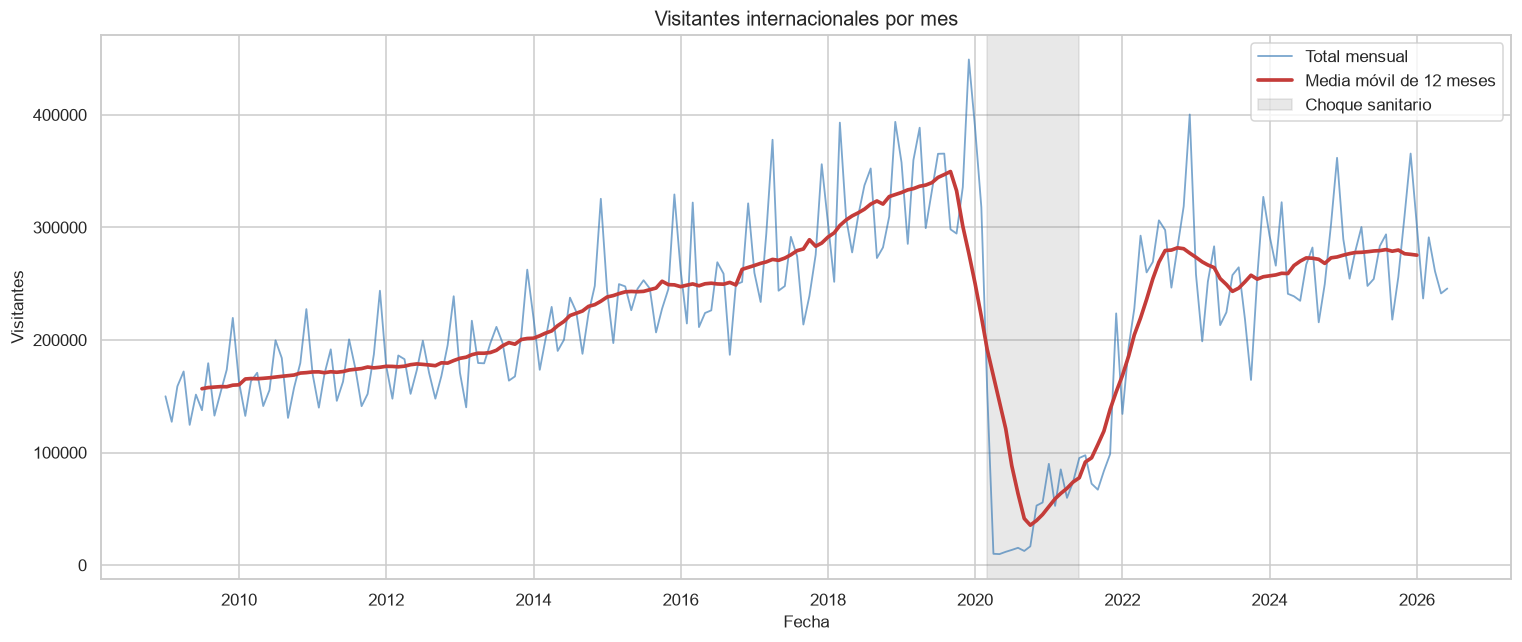

In [9]:
media_movil = serie_mensual.rolling(12, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(serie_mensual, color="#3679B5", alpha=0.65, lw=1.2, label="Total mensual")
ax.plot(media_movil, color="#C43C39", lw=2.4, label="Media móvil de 12 meses")
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-01"),
           color="gray", alpha=0.18, label="Choque sanitario")
ax.set(
    title="Visitantes internacionales por mes",
    xlabel="Fecha",
    ylabel="Visitantes"
)
ax.legend()
plt.tight_layout()
plt.show()

Antes de 2020 se aprecia una trayectoria creciente con oscilaciones anuales. El colapso iniciado en marzo de 2020 rompe abruptamente el nivel y domina la variabilidad histórica. La recuperación posterior es clara, aunque la comparación debe considerar que 2026 solo contiene seis meses.

,Visitantes,Variación anual (%),Índice 2019=100
Año,,,
2009,"1,880,182.85",NaN,45.50
2010,"2,004,784.00",6.63,48.52
2011,"2,079,714.60",3.74,50.33
2012,"2,139,541.48",2.88,51.78
2013,"2,289,702.75",7.02,55.41
2014,"2,660,177.32",16.18,64.38
2015,"2,917,886.04",9.69,70.61
2016,"2,997,026.74",2.71,72.53
2017,"3,307,651.29",10.36,80.04


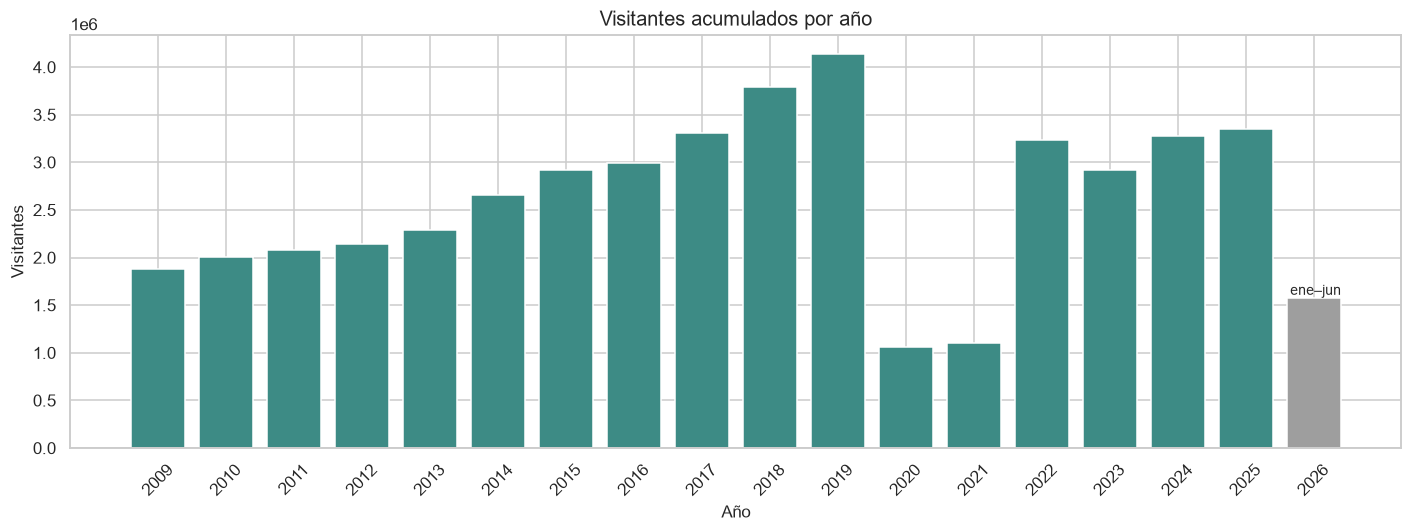

In [10]:
anual = visitantes.groupby("Año")["Viajero"].sum()
comparacion_anual = anual.to_frame("Visitantes")
comparacion_anual["Variación anual (%)"] = anual.pct_change() * 100
comparacion_anual["Índice 2019=100"] = 100 * anual / anual.loc[2019]
display(comparacion_anual)

colores = np.where(anual.index == 2026, "#9E9E9E", "#3D8B85")
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(anual.index.astype(str), anual.values, color=colores)
ax.set(
    title="Visitantes acumulados por año",
    xlabel="Año",
    ylabel="Visitantes"
)
ax.tick_params(axis="x", rotation=45)
ax.text(
    len(anual) - 1, anual.iloc[-1], " ene–jun",
    ha="center", va="bottom", fontsize=9
)
plt.tight_layout()
plt.show()

La comparación anual cuantifica el impacto de 2020 y la recuperación. El índice con base 2019 evita confundir crecimiento porcentual desde un piso muy bajo con recuperación completa. El total de 2026 no es comparable con años completos.

## 5. Países y regiones con mayor volumen

Los rankings se calculan con el acumulado de todo el período. La columna `País` pasa de países individuales a agrupaciones de mercado desde 2023; por ello sirve para describir concentración acumulada, pero las categorías pequeñas no deben interpretarse como series homogéneas durante los 210 meses.

,País,Viajero,Participación (%)
58,El Salvador,"14,079,135.77",30.14
84,Guatemala,"13,870,391.35",29.69
65,Estados Unidos de América,"6,965,679.71",14.91
91,Honduras,"2,520,974.31",5.40
143,México,"1,678,422.55",3.59
20,Belice,"916,101.07",1.96
48,Costa Rica,"860,240.69",1.84
148,Nicaragua,"811,145.39",1.74
45,Colombia,"549,494.69",1.18
38,Canadá,"516,707.89",1.11


,Región dos,Viajero,Participación (%)
1,América Del Centro,"33,283,931.98",71.25
2,América Del Norte,"9,160,810.15",19.61
5,Europa,"2,149,271.06",4.60
3,América Del Sur y el Caribe,"1,413,590.32",3.03
4,Asia,"410,333.51",0.88
6,Oceanía,"135,505.37",0.29
7,Oriente Medio,"133,735.19",0.29
8,Otros Paises Del Mundo,"23,914.30",0.05
0,0,821.00,0.00


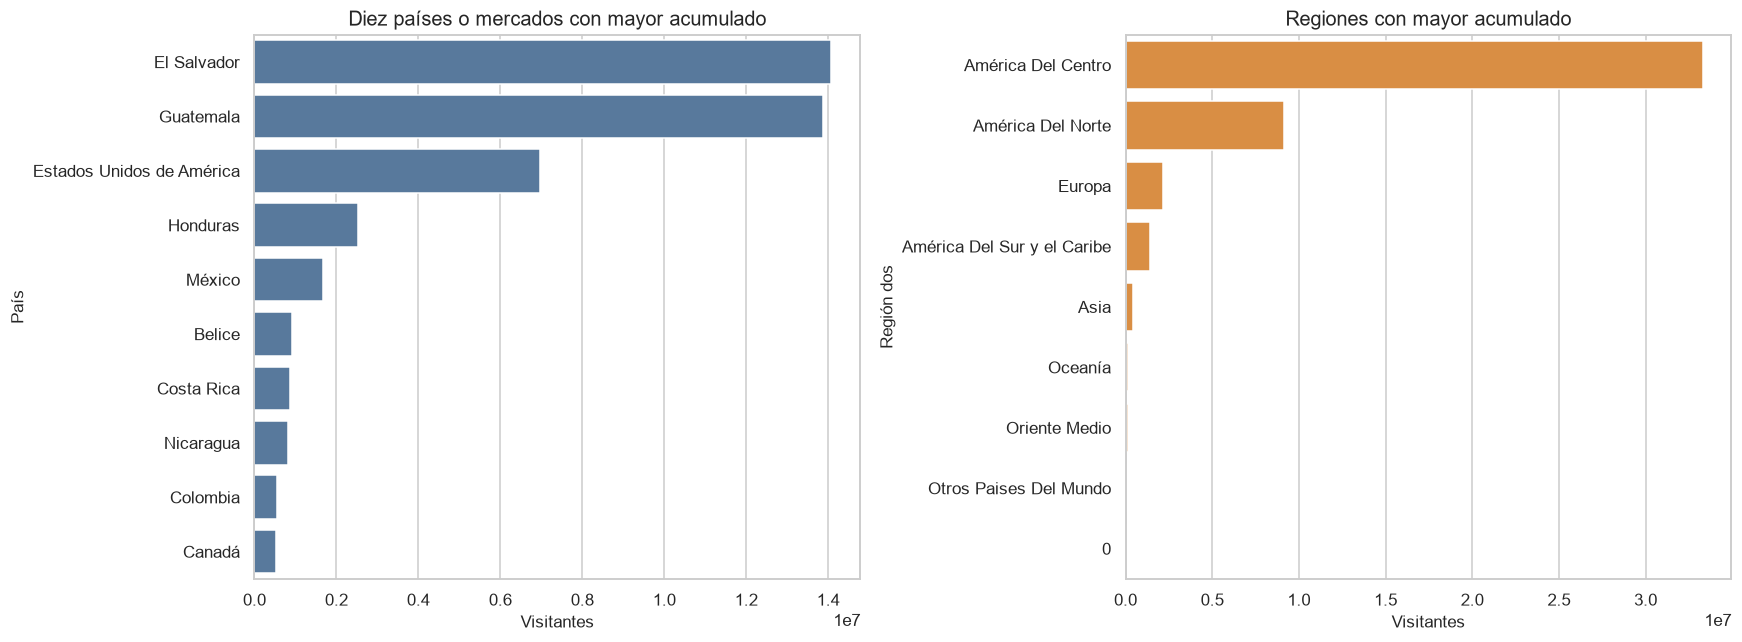

In [11]:
def tabla_top(data, categoria, n=10):
    salida = (
        data.groupby(categoria, as_index=False)["Viajero"]
            .sum()
            .sort_values("Viajero", ascending=False)
            .head(n)
            .copy()
    )
    salida["Participación (%)"] = (
        100 * salida["Viajero"] / data["Viajero"].sum()
    )
    return salida

top_paises = tabla_top(visitantes, "País", 10)
top_regiones = tabla_top(visitantes, "Región dos", 10)
display(top_paises)
display(top_regiones)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(
    data=top_paises, y="País", x="Viajero",
    color="#4C78A8", ax=axes[0]
)
sns.barplot(
    data=top_regiones, y="Región dos", x="Viajero",
    color="#F28E2B", ax=axes[1]
)
axes[0].set_title("Diez países o mercados con mayor acumulado")
axes[1].set_title("Regiones con mayor acumulado")
axes[0].set_xlabel("Visitantes")
axes[1].set_xlabel("Visitantes")
plt.tight_layout()
plt.show()

El flujo está fuertemente concentrado en mercados cercanos y en Norteamérica. `América Del Centro` domina el acumulado regional, lo que anticipa la importancia de los pasos terrestres. La aparición de Guatemala como residencia es posible en movimientos de residentes que ingresan al país y debe distinguirse de la nacionalidad.

## 6. Vías y fronteras de ingreso

Se compara la participación de las tres vías y se identifican las fronteras con mayor acumulado. Las fronteras representan puntos de control específicos; por eso su concentración complementa la lectura por vía.

,Vía,Viajero,Participación (%)
2,Terrestre,"27,592,253.33",59.07
0,Aérea,"19,019,418.55",40.72
1,Marítima,"100,241.00",0.21


,Frontera,Viajero,Participación (%)
0,01 La Aurora,"18,989,984.61",40.65
6,07 Valle Nuevo,"10,143,045.32",21.71
8,09 San Cristóbal,"4,183,631.71",8.96
7,08 Pedro de Alvarado,"3,764,229.26",8.06
9,10 La Ermita (Nueva Anguiatú),"2,587,072.27",5.54
19,20 Melchor de Mencos,"1,782,864.39",3.82
12,13 El Cinchado / El Corinto,"1,213,485.14",2.60
10,11 Agua Caliente,"922,419.53",1.97
11,12 El Florido,"910,373.47",1.95
14,15 El Carmen,"852,663.13",1.83


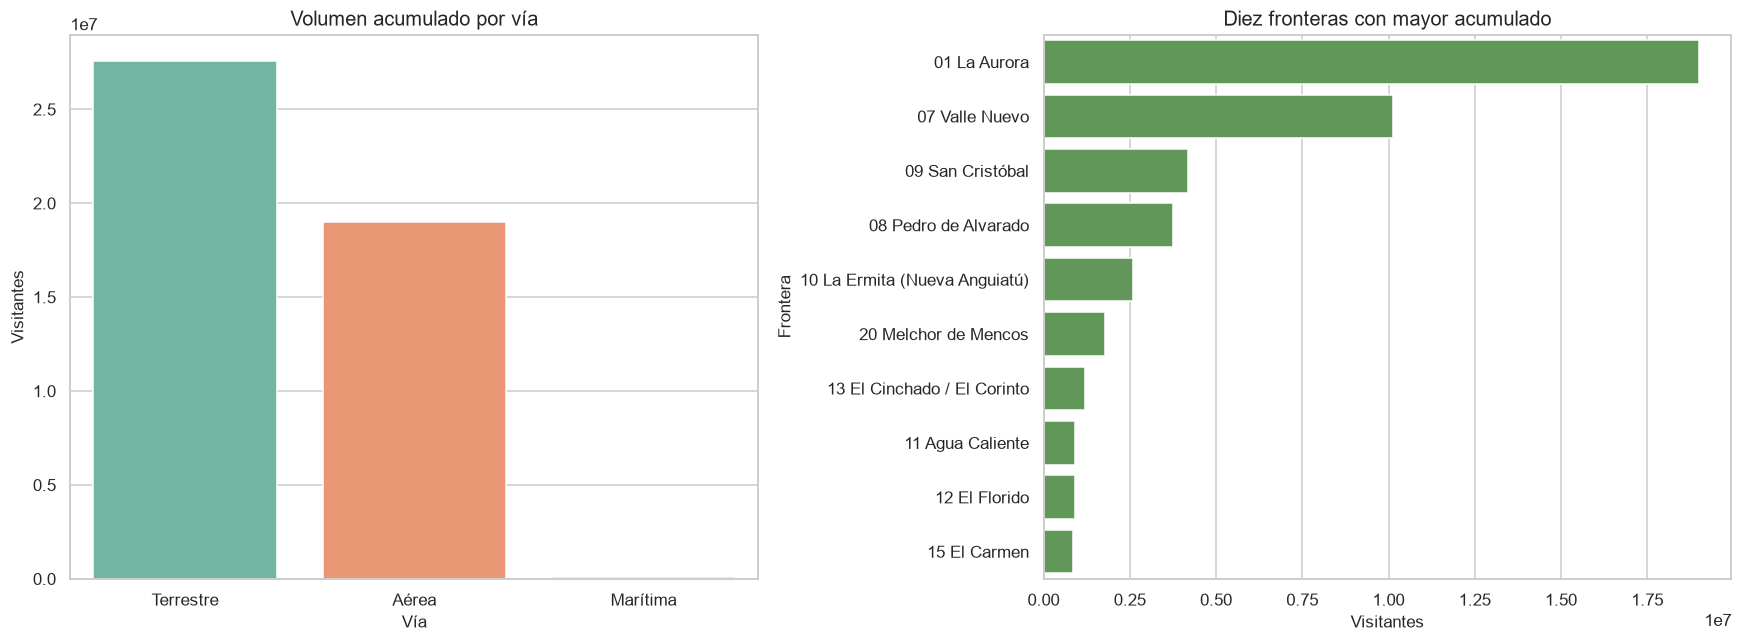

In [12]:
top_vias = tabla_top(visitantes, "Vía", 10)
top_fronteras = tabla_top(visitantes, "Frontera", 10)
display(top_vias)
display(top_fronteras)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(
    data=top_vias, x="Vía", y="Viajero",
    hue="Vía", legend=False, palette="Set2", ax=axes[0]
)
sns.barplot(
    data=top_fronteras, y="Frontera", x="Viajero",
    color="#59A14F", ax=axes[1]
)
axes[0].set_title("Volumen acumulado por vía")
axes[1].set_title("Diez fronteras con mayor acumulado")
axes[0].set_ylabel("Visitantes")
axes[1].set_xlabel("Visitantes")
plt.tight_layout()
plt.show()

Las vías terrestre y aérea explican prácticamente todo el flujo comparable. La Aurora encabeza los puntos de ingreso por concentrar el tráfico aéreo, mientras que varios pasos terrestres acumulan volúmenes altos asociados a los mercados centroamericanos. La vía marítima requiere cautela porque perdió detalle desde 2017.

## 7. Cruce entre región y vía

El cruce muestra la distribución porcentual de cada región entre vías. Se normaliza por fila para evitar que el gran tamaño de una región oculte su patrón de acceso.

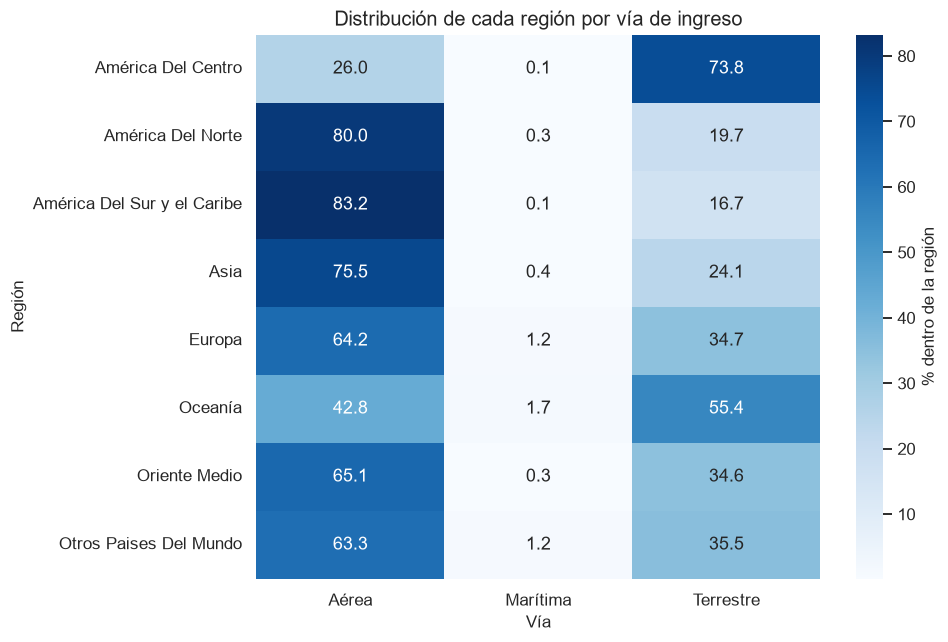

Vía,Aérea,Marítima,Terrestre
Región dos,,,
América Del Centro,26.02,0.13,73.84
América Del Norte,80.02,0.28,19.70
América Del Sur y el Caribe,83.24,0.11,16.65
Asia,75.52,0.37,24.10
Europa,64.19,1.15,34.66
Oceanía,42.84,1.72,55.44
Oriente Medio,65.06,0.30,34.64
Otros Paises Del Mundo,63.25,1.23,35.52


In [13]:
regiones_principales = top_regiones["Región dos"].head(8)
cruce = pd.pivot_table(
    visitantes.loc[visitantes["Región dos"].isin(regiones_principales)],
    index="Región dos",
    columns="Vía",
    values="Viajero",
    aggfunc="sum",
    fill_value=0
)
cruce_pct = cruce.div(cruce.sum(axis=1), axis=0) * 100

plt.figure(figsize=(9, 6))
sns.heatmap(
    cruce_pct, annot=True, fmt=".1f", cmap="Blues",
    cbar_kws={"label": "% dentro de la región"}
)
plt.title("Distribución de cada región por vía de ingreso")
plt.xlabel("Vía")
plt.ylabel("Región")
plt.tight_layout()
plt.show()
display(cruce_pct)

La composición confirma dos patrones distintos: Centroamérica depende principalmente de accesos terrestres, mientras que los mercados más distantes se concentran en la vía aérea. Esta diferencia implica que choques operativos o políticas aplicadas a una vía afectan de manera desigual a las regiones de origen.

## 8. Valores atípicos

El criterio IQR se aplica tanto al nivel fila como al total mensual. Una observación extrema no se elimina automáticamente: en una base agregada puede corresponder a una combinación legítima de alto volumen, a un mes estacionalmente fuerte o a un cambio estructural.

,Valor
Límite superior por registro,89.50
Registros marcados por IQR,"22,887.00"
Porcentaje de registros marcados,16.63
Límite superior mensual,"439,781.31"
Meses marcados por IQR,1.00


,Visitantes
Fecha,
2019-12-01,"449,114.07"


,Fecha,Vía,Frontera,País,Región dos,Tipo de Viajero,Viajero
125467,2019-12-01,Aérea,01 La Aurora,Guatemala,América Del Centro,Turista,"83,511.00"
113803,2018-12-01,Aérea,01 La Aurora,Guatemala,América Del Centro,Turista,"81,030.06"
143830,2022-12-01,Aérea,01 La Aurora,Guatemala,América Del Centro,Turista,"76,588.00"
101676,2017-12-01,Aérea,01 La Aurora,Guatemala,América Del Centro,Turista,"72,545.00"
158529,2025-12-01,Terrestre,07 Valle Nuevo,El Salvador,América Del Centro,Turista,"69,806.00"
124479,2019-11-01,Aérea,01 La Aurora,Guatemala,América Del Centro,Turista,"68,877.00"
153378,2024-12-01,Terrestre,07 Valle Nuevo,El Salvador,América Del Centro,Turista,"68,085.77"
158552,2025-12-01,Aérea,01 La Aurora,Estados Unidos de América,América Del Norte,Turista,"67,952.00"
77647,2015-12-01,Aérea,01 La Aurora,Guatemala,América Del Centro,Turista,"67,786.00"
112766,2018-11-01,Aérea,01 La Aurora,Guatemala,América Del Centro,Turista,"66,196.24"


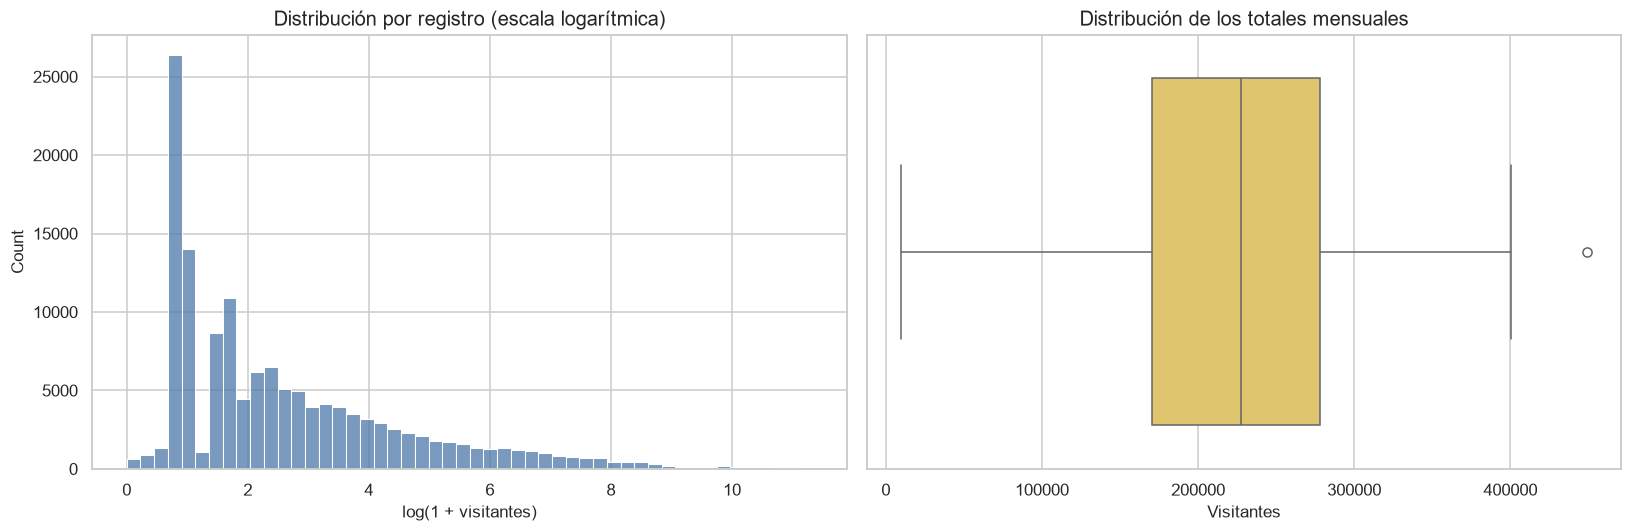

In [14]:
def limites_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

lim_inf_fila, lim_sup_fila = limites_iqr(visitantes["Viajero"])
lim_inf_mes, lim_sup_mes = limites_iqr(serie_mensual)

atipicos_fila = visitantes.loc[
    (visitantes["Viajero"] < lim_inf_fila)
    | (visitantes["Viajero"] > lim_sup_fila)
]
atipicos_mes = serie_mensual.loc[
    (serie_mensual < lim_inf_mes) | (serie_mensual > lim_sup_mes)
]

resumen_atipicos = pd.Series({
    "Límite superior por registro": lim_sup_fila,
    "Registros marcados por IQR": len(atipicos_fila),
    "Porcentaje de registros marcados": 100 * len(atipicos_fila) / len(visitantes),
    "Límite superior mensual": lim_sup_mes,
    "Meses marcados por IQR": len(atipicos_mes)
}, name="Valor")
display(resumen_atipicos.to_frame())
display(atipicos_mes.to_frame("Visitantes"))
display(
    atipicos_fila.nlargest(10, "Viajero")[
        ["Fecha", "Vía", "Frontera", "País", "Región dos",
         "Tipo de Viajero", "Viajero"]
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(np.log1p(visitantes["Viajero"]), bins=50, ax=axes[0], color="#4C78A8")
axes[0].set(
    title="Distribución por registro (escala logarítmica)",
    xlabel="log(1 + visitantes)"
)
sns.boxplot(x=serie_mensual.values, ax=axes[1], color="#F2CF5B")
axes[1].set(
    title="Distribución de los totales mensuales",
    xlabel="Visitantes"
)
plt.tight_layout()
plt.show()

La asimetría por registro es esperable: existen muchas combinaciones pequeñas y pocas combinaciones de mercados masivos. Por ello, eliminar todos los registros marcados por IQR destruiría señal real. Los meses extremos se conservan y se interpretan en su contexto temporal.

## 9. División cronológica de entrenamiento y prueba

La partición respeta el orden temporal para impedir que información futura entre al entrenamiento. El 70% inicial de los meses se usa para entrenar y el 30% final para prueba; todas las filas de un mismo mes permanecen en el mismo conjunto.

,Conjunto,Inicio,Fin,Meses,Porcentaje de meses,Filas
0,Entrenamiento,2009-01-01,2021-03-01,147,70.00,116966
1,Prueba,2021-04-01,2026-06-01,63,30.00,20676


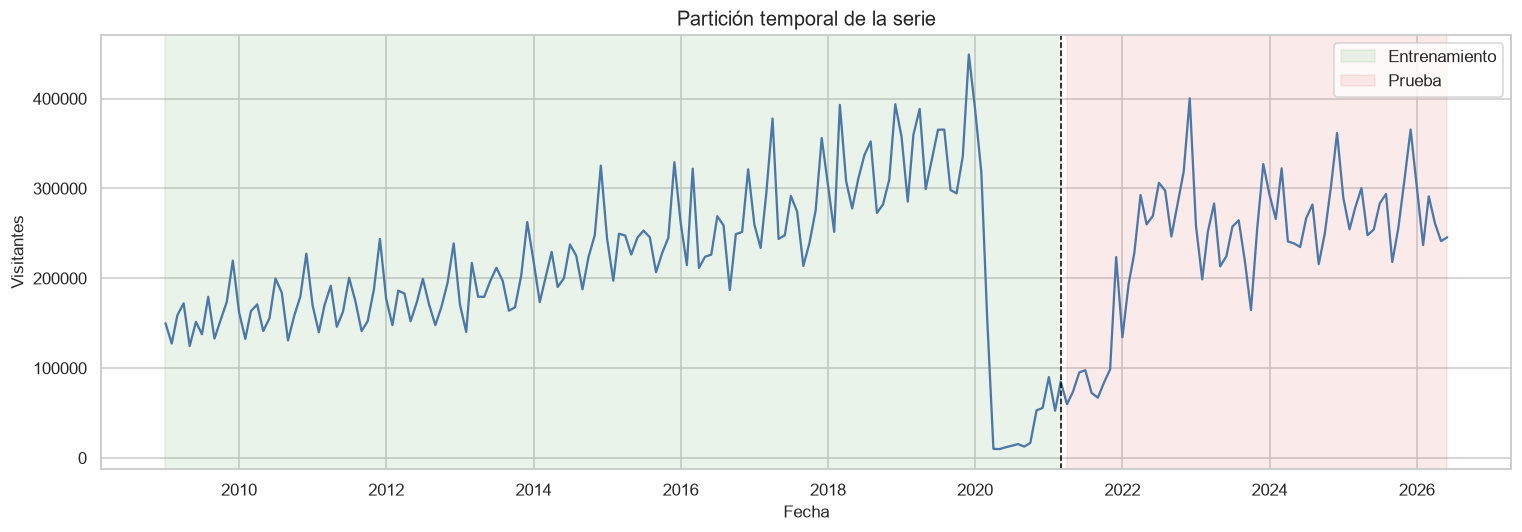

In [15]:
fechas = pd.DatetimeIndex(sorted(visitantes["Fecha"].unique()))
n_train = int(np.floor(0.70 * len(fechas)))
fechas_train = fechas[:n_train]
fechas_test = fechas[n_train:]
fecha_corte = fechas_train[-1]

train = visitantes.loc[visitantes["Fecha"].isin(fechas_train)].copy()
test = visitantes.loc[visitantes["Fecha"].isin(fechas_test)].copy()

particion = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Prueba"],
    "Inicio": [fechas_train.min(), fechas_test.min()],
    "Fin": [fechas_train.max(), fechas_test.max()],
    "Meses": [len(fechas_train), len(fechas_test)],
    "Porcentaje de meses": [
        100 * len(fechas_train) / len(fechas),
        100 * len(fechas_test) / len(fechas)
    ],
    "Filas": [len(train), len(test)]
})
display(particion)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(serie_mensual, color="#4C78A8", lw=1.5)
ax.axvspan(fechas_train.min(), fechas_train.max(), color="#59A14F",
           alpha=0.12, label="Entrenamiento")
ax.axvspan(fechas_test.min(), fechas_test.max(), color="#E15759",
           alpha=0.12, label="Prueba")
ax.axvline(fecha_corte, color="black", ls="--", lw=1)
ax.set(
    title="Partición temporal de la serie",
    xlabel="Fecha",
    ylabel="Visitantes"
)
ax.legend()
plt.tight_layout()
plt.show()

La prueba comienza inmediatamente después del último mes de entrenamiento. Esta partición es exigente: el entrenamiento termina cerca del período de disrupción, mientras que la prueba contiene buena parte de la recuperación y un entorno de nivel distinto. Esa dificultad representa un cambio estructural real y deberá considerarse al evaluar pronósticos.

## 10. Construcción de las series mensuales

Se construye una serie total y dos categorías completas: las tres vías de ingreso y las tres regiones con mayor volumen acumulado. El Top 3 regional se determina con todo el período para que el ranking no dependa de un año particular; los valores mensuales usados para modelar proceden únicamente del entrenamiento.

In [16]:
indice_train = pd.date_range(fechas_train.min(), fechas_train.max(), freq="MS")

top3_regiones = (
    visitantes.groupby("Región dos")["Viajero"]
              .sum()
              .nlargest(3)
              .index
              .tolist()
)
vias_requeridas = ["Aérea", "Terrestre", "Marítima"]

serie_total_train = (
    train.groupby("Fecha")["Viajero"]
         .sum()
         .reindex(indice_train, fill_value=0)
         .rename("Total")
)

series_via_train = (
    train.pivot_table(
        index="Fecha", columns="Vía", values="Viajero",
        aggfunc="sum", fill_value=0
    )
    .reindex(index=indice_train, columns=vias_requeridas, fill_value=0)
)

series_region_train = (
    train.loc[train["Región dos"].isin(top3_regiones)]
         .pivot_table(
             index="Fecha", columns="Región dos", values="Viajero",
             aggfunc="sum", fill_value=0
         )
         .reindex(index=indice_train, columns=top3_regiones, fill_value=0)
)

series_construidas = {"Total": serie_total_train}
series_construidas.update({
    f"Vía — {col}": series_via_train[col] for col in series_via_train
})
series_construidas.update({
    f"Región — {col}": series_region_train[col] for col in series_region_train
})

metadatos_series = pd.DataFrame([
    {
        "Serie": nombre,
        "Inicio": serie.index.min(),
        "Fin": serie.index.max(),
        "Frecuencia": "Mensual (MS)",
        "Observaciones": len(serie),
        "Meses faltantes": int(serie.isna().sum())
    }
    for nombre, serie in series_construidas.items()
])

print("Top 3 de regiones:", ", ".join(top3_regiones))
display(metadatos_series)

Top 3 de regiones: América Del Centro, América Del Norte, Europa


,Serie,Inicio,Fin,Frecuencia,Observaciones,Meses faltantes
0,Total,2009-01-01,2021-03-01,Mensual (MS),147,0
1,Vía — Aérea,2009-01-01,2021-03-01,Mensual (MS),147,0
2,Vía — Terrestre,2009-01-01,2021-03-01,Mensual (MS),147,0
3,Vía — Marítima,2009-01-01,2021-03-01,Mensual (MS),147,0
4,Región — América Del Centro,2009-01-01,2021-03-01,Mensual (MS),147,0
5,Región — América Del Norte,2009-01-01,2021-03-01,Mensual (MS),147,0
6,Región — Europa,2009-01-01,2021-03-01,Mensual (MS),147,0


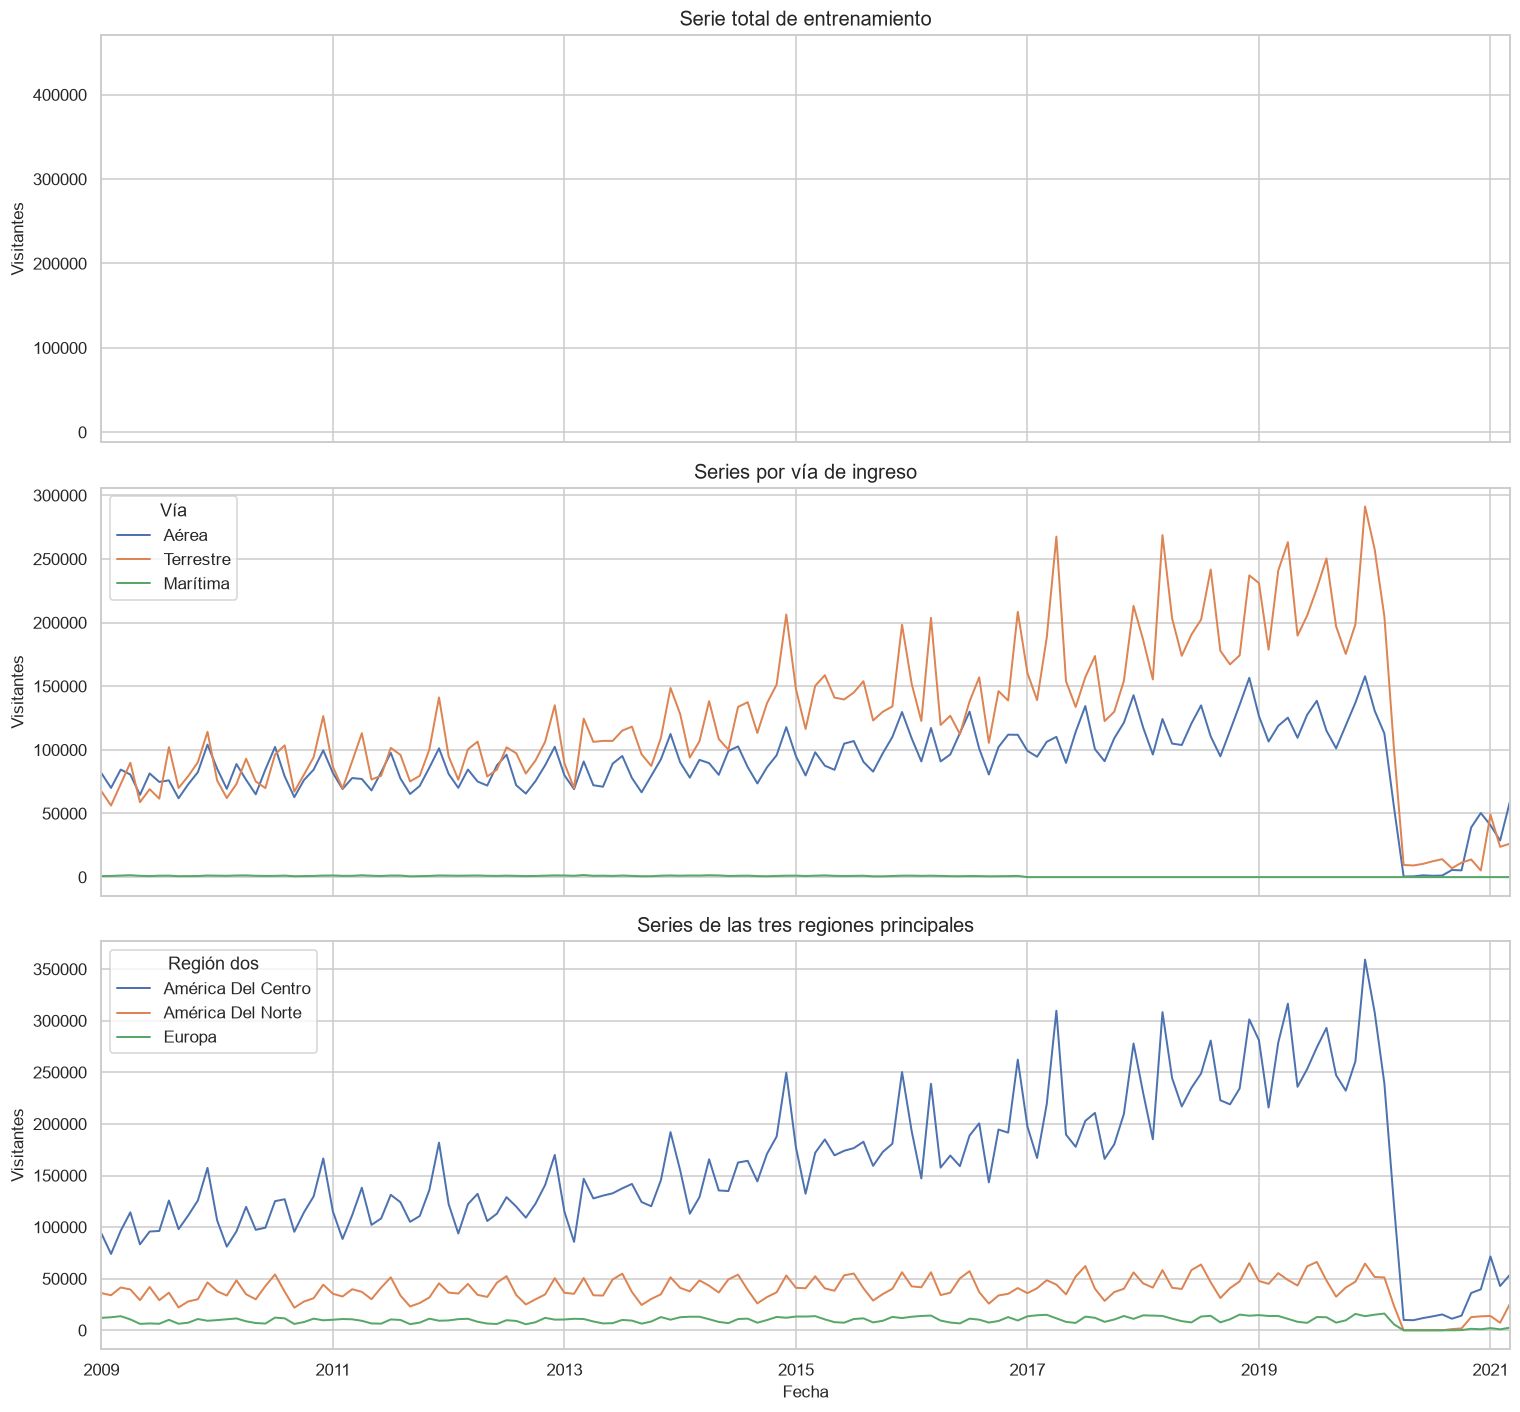

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)

axes[0].plot(serie_total_train, color="#222222", lw=1.5)
axes[0].set_title("Serie total de entrenamiento")
axes[0].set_ylabel("Visitantes")

series_via_train.plot(ax=axes[1], lw=1.3)
axes[1].set_title("Series por vía de ingreso")
axes[1].set_ylabel("Visitantes")

series_region_train.plot(ax=axes[2], lw=1.3)
axes[2].set_title("Series de las tres regiones principales")
axes[2].set_ylabel("Visitantes")
axes[2].set_xlabel("Fecha")

plt.tight_layout()
plt.show()

Las series no presentan huecos y comparten inicio, fin y frecuencia, lo que permite compararlas directamente. La suma por vía coincide con el total mensual; las tres regiones principales son subconjuntos y no necesariamente cubren el cien por ciento.

## 11. Análisis de dos series seleccionadas

Se profundiza en las vías `Aérea` y `Terrestre`, las dos de mayor volumen. La descomposición aditiva separa tendencia, patrón estacional de 12 meses y residuo. También se cuantifican la fuerza de tendencia y estacionalidad, la volatilidad relativa y el impacto anual de la pandemia.

In [18]:
series_analisis = {
    "Vía aérea": series_via_train["Aérea"].astype(float),
    "Vía terrestre": series_via_train["Terrestre"].astype(float)
}

def fuerza_componentes(descomp):
    residuo = descomp.resid.dropna()
    tendencia = descomp.trend.reindex(residuo.index)
    estacional = descomp.seasonal.reindex(residuo.index)
    fuerza_tendencia = max(
        0, 1 - np.var(residuo) / np.var(tendencia + residuo)
    )
    fuerza_estacional = max(
        0, 1 - np.var(residuo) / np.var(estacional + residuo)
    )
    return fuerza_tendencia, fuerza_estacional

descomposiciones = {}
metricas_componentes = []

for nombre, serie in series_analisis.items():
    descomp = seasonal_decompose(
        serie, model="additive", period=12, extrapolate_trend="freq"
    )
    descomposiciones[nombre] = descomp
    ft, fe = fuerza_componentes(descomp)
    metricas_componentes.append({
        "Serie": nombre,
        "Inicio": serie.index.min(),
        "Fin": serie.index.max(),
        "Frecuencia": "Mensual",
        "Media": serie.mean(),
        "Desviación estándar": serie.std(),
        "Coeficiente de variación": serie.std() / serie.mean(),
        "Fuerza de tendencia": ft,
        "Fuerza de estacionalidad": fe
    })

display(pd.DataFrame(metricas_componentes).set_index("Serie"))

,Inicio,Fin,Frecuencia,Media,Desviación estándar,Coeficiente de variación,Fuerza de tendencia,Fuerza de estacionalidad
Serie,,,,,,,,
Vía aérea,2009-01-01,2021-03-01,Mensual,"89,061.66","29,560.55",0.33,0.67,0.41
Vía terrestre,2009-01-01,2021-03-01,Mensual,"124,474.33","60,636.81",0.49,0.78,0.36


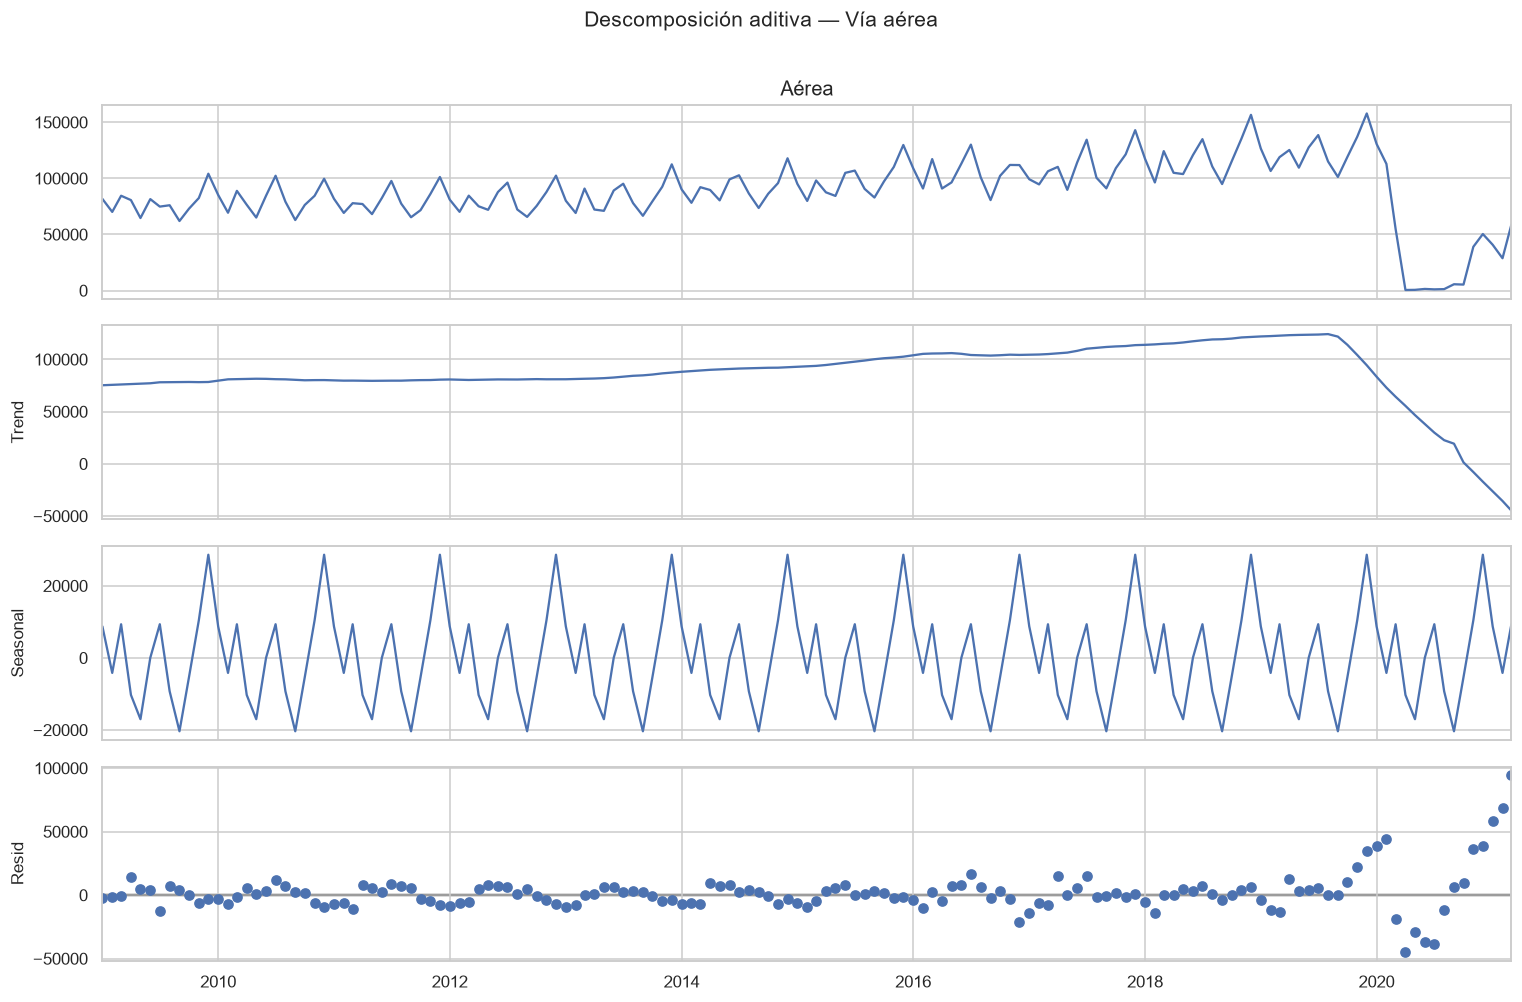

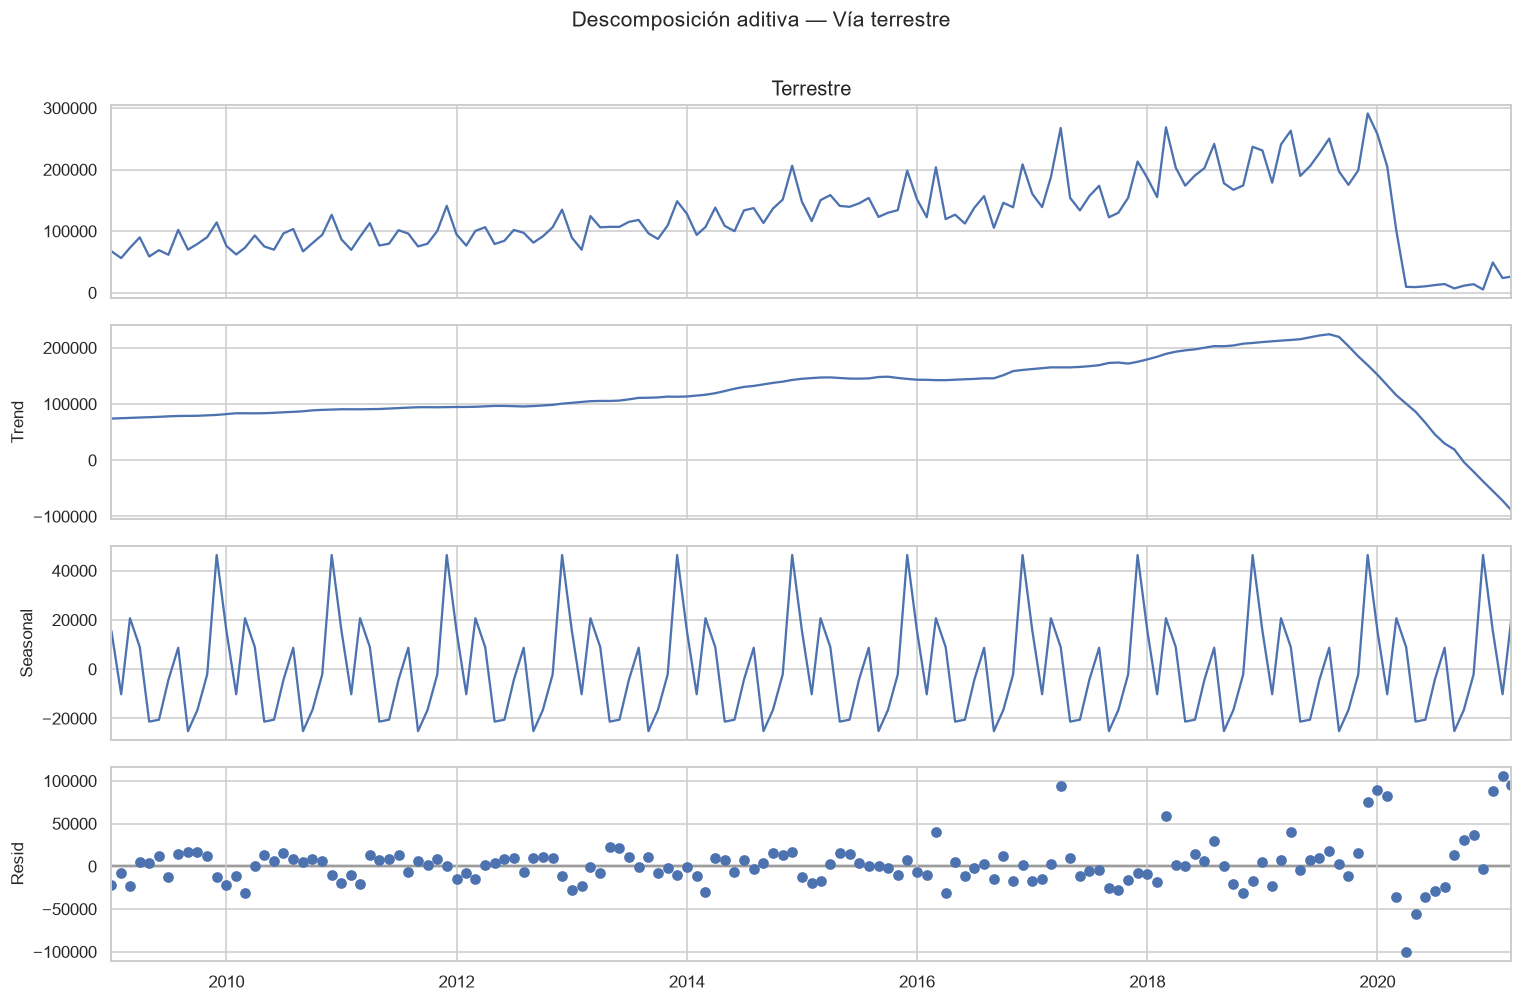

In [19]:
for nombre, descomp in descomposiciones.items():
    fig = descomp.plot()
    fig.set_size_inches(14, 9)
    fig.suptitle(f"Descomposición aditiva — {nombre}", y=1.01, fontsize=14)
    plt.tight_layout()
    plt.show()

Ambas vías muestran un nivel cambiante y un patrón anual, de modo que no se comportan como ruido alrededor de una media fija. La caída extraordinaria de 2020 aparece en la tendencia y, sobre todo, en el residuo porque no es un patrón estacional recurrente. La fuerza estacional permite comparar la regularidad del ciclo anual sin depender de la escala de cada vía.

### Pandemia y recuperación

Para medir el cambio se comparan años completos contra 2019. La tabla se calcula sobre la serie completa, no sobre el conjunto de prueba aislado, y separa el efecto por vía.

In [20]:
series_via_full = (
    visitantes.pivot_table(
        index="Fecha", columns="Vía", values="Viajero",
        aggfunc="sum", fill_value=0
    )
    .reindex(index=meses_esperados, columns=vias_requeridas, fill_value=0)
)
anual_vias = series_via_full.resample("YS").sum()
anios_comparacion = [2019, 2020, 2021, 2022, 2023, 2024, 2025]

impacto = anual_vias.loc[
    anual_vias.index.year.isin(anios_comparacion), ["Aérea", "Terrestre"]
].copy()
impacto.index = impacto.index.year
impacto.columns = ["Aérea — nivel", "Terrestre — nivel"]
impacto["Aérea — índice 2019=100"] = (
    100 * impacto["Aérea — nivel"] / impacto.loc[2019, "Aérea — nivel"]
)
impacto["Terrestre — índice 2019=100"] = (
    100 * impacto["Terrestre — nivel"] / impacto.loc[2019, "Terrestre — nivel"]
)
display(impacto)

,Aérea — nivel,Terrestre — nivel,Aérea — índice 2019=100,Terrestre — índice 2019=100
Fecha,,,,
2019,"1,483,385.91","2,648,864.69",100.00,100.00
2020,"403,524.93","656,245.51",27.20,24.77
2021,"703,471.24","395,493.14",47.42,14.93
2022,"1,390,275.00","1,839,053.60",93.72,69.43
2023,"985,840.00","1,931,986.81",66.46,72.94
2024,"1,143,353.00","2,131,083.00",77.08,80.45
2025,"1,188,971.00","2,163,317.66",80.15,81.67


Los índices hacen visible la profundidad del choque y la velocidad de recuperación de cada vía. Una recuperación porcentual grande después de 2020 no implica por sí sola haber alcanzado el nivel de 2019; para ello el índice debe acercarse o superar 100.

### Media, varianza y autocorrelación

Se comparan medias y desviaciones móviles, la prueba Dickey–Fuller aumentada (ADF) y la autocorrelación. La hipótesis nula de ADF es que existe raíz unitaria; un valor p menor que 0.05 aporta evidencia de estacionariedad en media. La primera diferencia logarítmica estudia cambios proporcionales y reduce simultáneamente tendencia y variación dependiente del nivel.

In [21]:
def resultado_adf(serie, etiqueta):
    limpia = pd.Series(serie).dropna()
    estadistico, pvalor, rezagos, nobs, *_ = adfuller(
        limpia, autolag="AIC"
    )
    return {
        "Transformación": etiqueta,
        "Estadístico ADF": estadistico,
        "p-valor": pvalor,
        "Rezagos": rezagos,
        "Observaciones": nobs,
        "Estacionaria al 5%": pvalor < 0.05
    }

resultados_adf = []
for nombre, serie in series_analisis.items():
    log_serie = np.log1p(serie)
    diferencia_log = log_serie.diff()
    resultados_adf.append({
        "Serie": nombre, **resultado_adf(serie, "Nivel")
    })
    resultados_adf.append({
        "Serie": nombre, **resultado_adf(diferencia_log, "Δ log(1+x)")
    })

display(pd.DataFrame(resultados_adf).set_index(["Serie", "Transformación"]))

Estadístico ADF  p-valor  Rezagos  \
Serie         Transformación                                      
Vía aérea     Nivel                     -2.37     0.15       14   
              Δ log(1+x)                -3.09     0.03       11   
Vía terrestre Nivel                     -2.12     0.24       13   
              Δ log(1+x)                -3.12     0.02       11   

                              Observaciones  Estacionaria al 5%  
Serie         Transformación                                     
Vía aérea     Nivel                     132               False  
              Δ log(1+x)                134                True  
Vía terrestre Nivel                     133               False  
              Δ log(1+x)                134                True

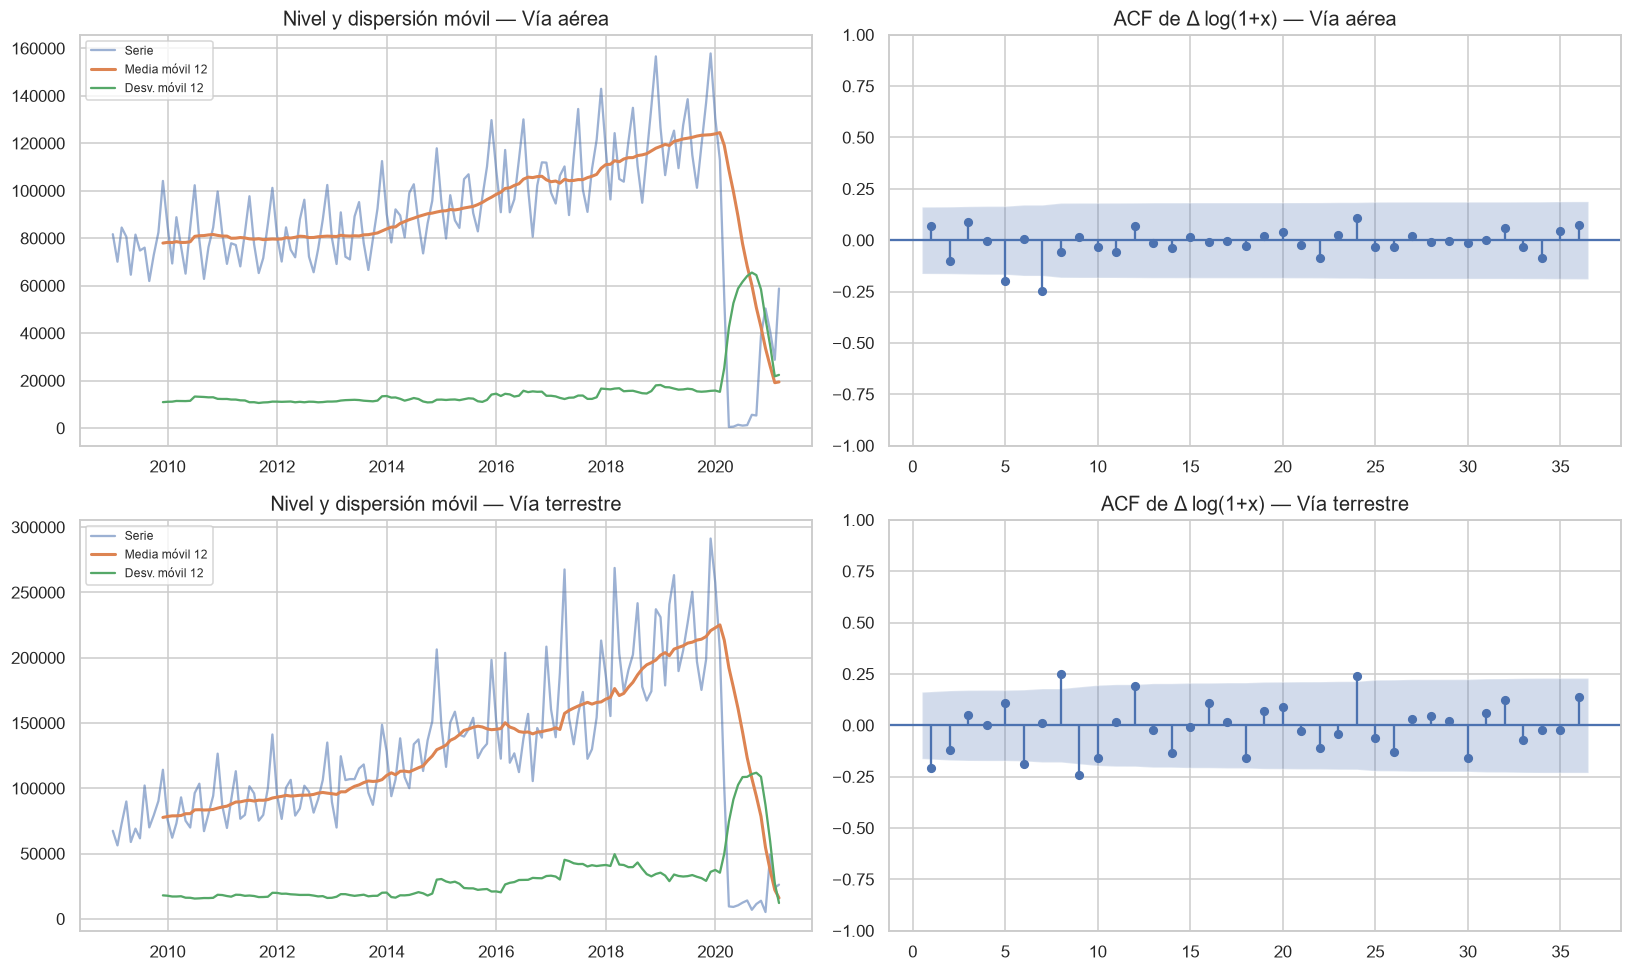

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

for fila, (nombre, serie) in enumerate(series_analisis.items()):
    media12 = serie.rolling(12).mean()
    std12 = serie.rolling(12).std()
    axes[fila, 0].plot(serie, alpha=0.55, label="Serie")
    axes[fila, 0].plot(media12, lw=2, label="Media móvil 12")
    axes[fila, 0].plot(std12, lw=1.5, label="Desv. móvil 12")
    axes[fila, 0].set_title(f"Nivel y dispersión móvil — {nombre}")
    axes[fila, 0].legend(fontsize=8)

    plot_acf(
        np.log1p(serie).diff().dropna(),
        lags=36,
        ax=axes[fila, 1],
        zero=False
    )
    axes[fila, 1].set_title(f"ACF de Δ log(1+x) — {nombre}")

plt.tight_layout()
plt.show()

La media móvil confirma que el nivel cambia a través del tiempo. La dispersión también varía y aumenta en períodos de mayor flujo, por lo que la transformación logarítmica es razonable antes de modelar. La persistencia de picos en rezagos cercanos a 12 en la ACF indica estacionalidad anual; si permanece tras la primera diferencia, será necesario evaluar una diferencia estacional adicional en la etapa de modelado.